# Iris Flower Classification

## 1. Introduction

The Iris Flower Classification project aims to classify iris flowers into three species:
- Setosa
- Versicolor
- Virginica

The classification is based on four physical measurements:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

We will use the Iris dataset provided by scikit-learn and train machine learning classification models to predict the flower species.

In [1]:
# Import required libraries
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df["target"] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# Check the shape of the dataset
print("Dataset shape:", df.shape)

Dataset shape: (150, 5)


In [3]:
# Check the data types of each column
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object


In [4]:
# Check for missing values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [5]:
# Display descriptive statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


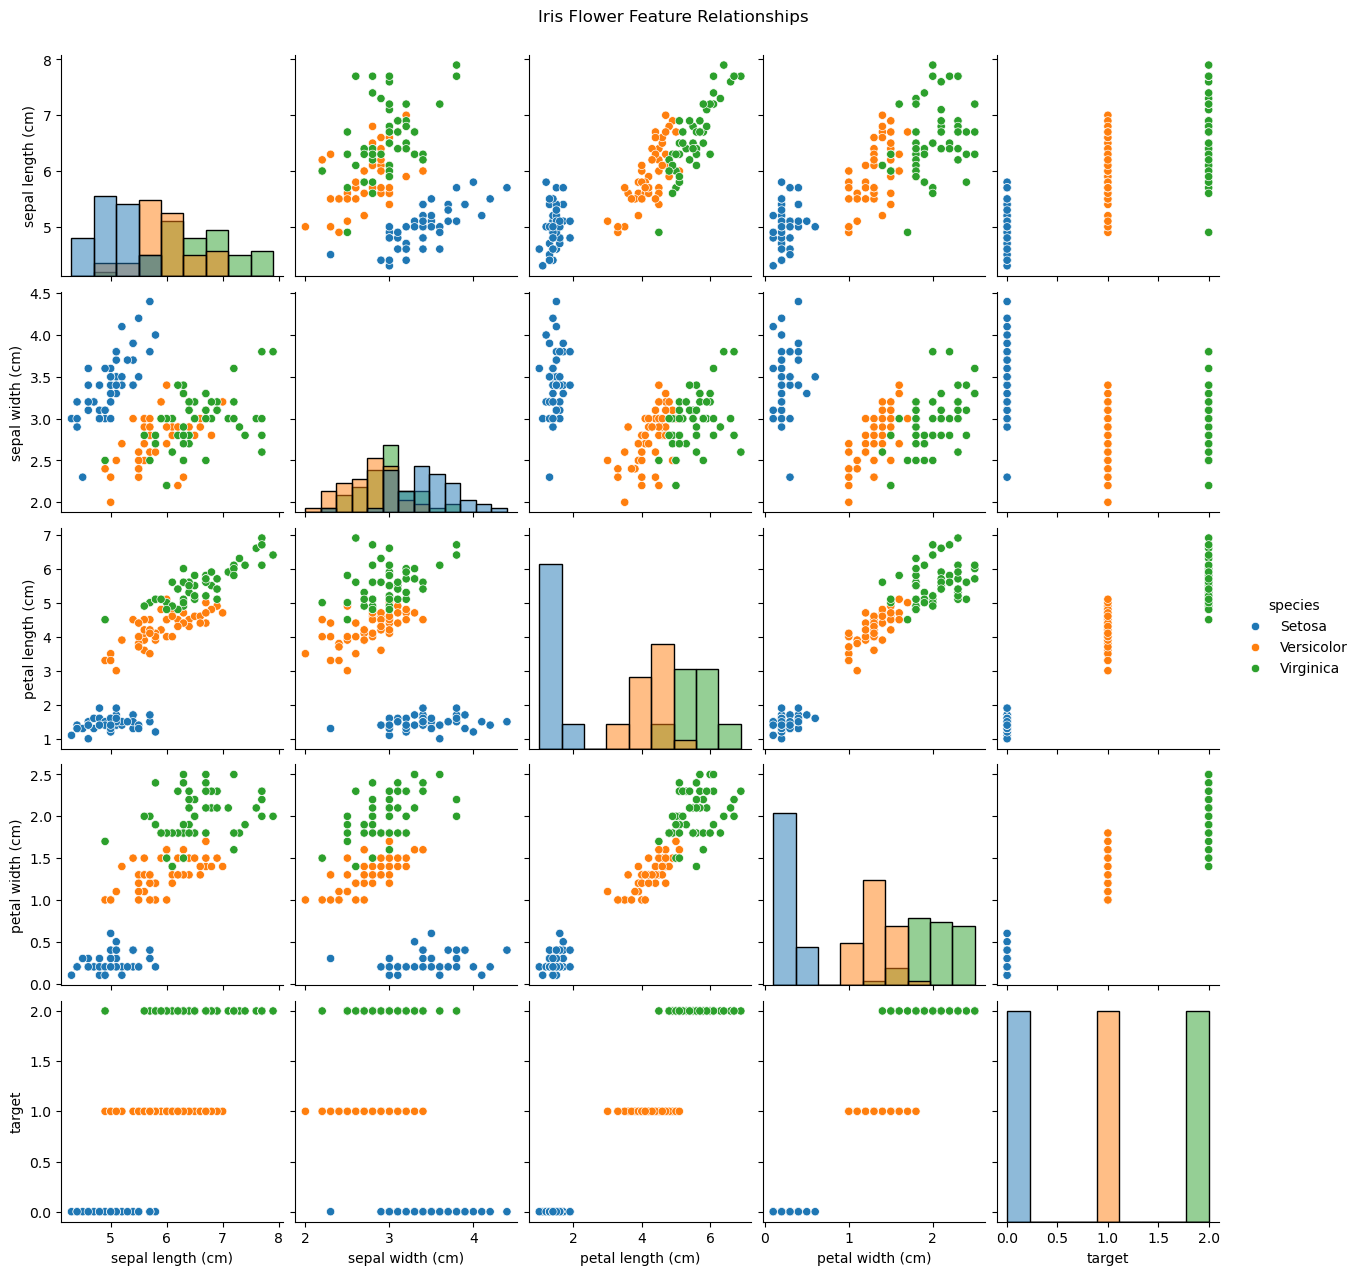

In [6]:
# Import visualization library
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy with species names
plot_df = df.copy()
plot_df["species"] = plot_df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Create pairplot
sns.pairplot(
    plot_df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle("Iris Flower Feature Relationships", y=1.02)
plt.show()

## Pairplot Analysis

The pairplot shows the relationships between the four numerical features of the Iris dataset.

Key observations:
- Petal length and petal width provide strong separation between the three Iris species.
- Setosa forms a clearly distinct cluster from Versicolor and Virginica.
- Versicolor and Virginica show some overlap, but they can still be distinguished using multiple features.
- Petal-related features appear to be particularly useful for classification.

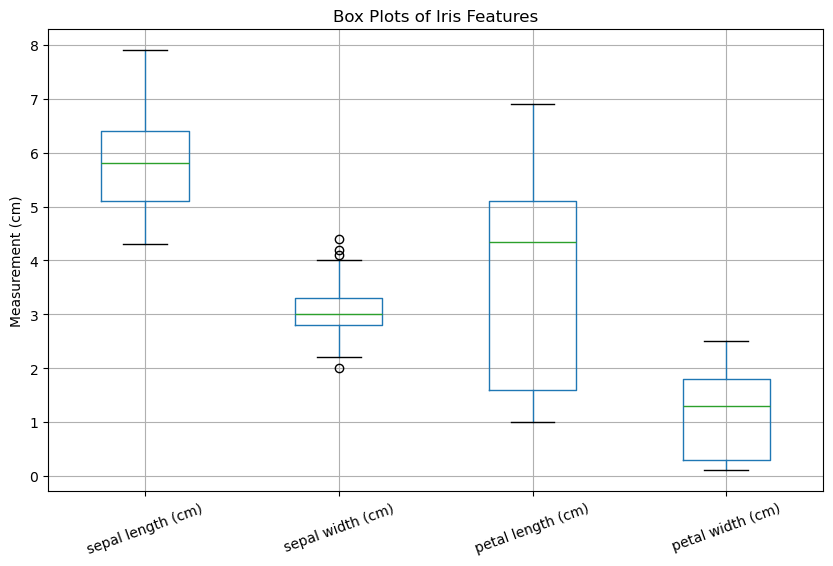

In [7]:
# Create box plots for the four features

features = iris.feature_names

plt.figure(figsize=(10, 6))
df[features].boxplot()

plt.title("Box Plots of Iris Features")
plt.ylabel("Measurement (cm)")
plt.xticks(rotation=20)
plt.show()

## Box Plot Analysis

The box plots show the distribution and spread of the four Iris features.

Key observations:
- Sepal length has a moderate spread with no major extreme values.
- Sepal width shows a few potential outliers.
- Petal length and petal width have wider ranges across the complete dataset.
- The feature distributions indicate that petal measurements may be especially useful for distinguishing the Iris species.

## Feature Selection Discussion

Based on the pairplot and box plots, petal length and petal width appear to be the most useful features for distinguishing the three Iris species.

Setosa is clearly separated from the other two species using petal measurements. Versicolor and Virginica have some overlap, but petal length and petal width still provide strong separation.

Therefore, petal length and petal width are expected to be important features for the classification models.

In [8]:
# Separate features (X) and target (y)

X = df.drop("target", axis=1)
y = df["target"]

# Display the shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [9]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


In [10]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [11]:
# Make predictions using Logistic Regression
y_pred_logistic = logistic_model.predict(X_test)

# Display the first 10 predictions
print("Predictions:", y_pred_logistic[:10])

Predictions: [0 2 1 1 0 1 0 0 2 1]


In [12]:
# Import accuracy score
from sklearn.metrics import accuracy_score

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression Accuracy (%):", logistic_accuracy * 100)

Logistic Regression Accuracy: 0.9666666666666667
Logistic Regression Accuracy (%): 96.66666666666667


In [13]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [14]:
# Make predictions using Decision Tree
y_pred_tree = decision_tree_model.predict(X_test)

# Display the first 10 predictions
print("Decision Tree Predictions:", y_pred_tree[:10])

Decision Tree Predictions: [0 2 1 1 0 1 0 0 2 1]


In [15]:
# Calculate Decision Tree accuracy
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Accuracy (%):", tree_accuracy * 100)

Decision Tree Accuracy: 0.9333333333333333
Decision Tree Accuracy (%): 93.33333333333333


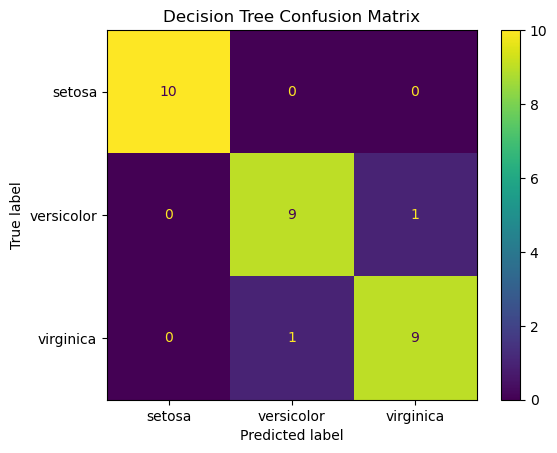

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_tree)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import classification_report

# Classification report for Decision Tree
print("Decision Tree Classification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=iris.target_names
))

Decision Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [18]:
# Compare model accuracies
print("Model Accuracy Comparison")
print("-------------------------")
print("Logistic Regression:", logistic_accuracy * 100, "%")
print("Decision Tree:", tree_accuracy * 100, "%")

if logistic_accuracy > tree_accuracy:
    print("\nBest Model: Logistic Regression")
else:
    print("\nBest Model: Decision Tree")

Model Accuracy Comparison
-------------------------
Logistic Regression: 96.66666666666667 %
Decision Tree: 93.33333333333333 %

Best Model: Logistic Regression


# Conclusion

The Iris Flower Classification project was completed using the Iris dataset.

Two machine learning classification models were trained and evaluated:
- Logistic Regression
- Decision Tree

The Logistic Regression model achieved an accuracy of 96.67%.
The Decision Tree model achieved an accuracy of 93.33%.

Therefore, Logistic Regression performed better on the test dataset and was selected as the best model.

The analysis also showed that petal length and petal width are important features for distinguishing the three Iris species.